In [1]:
%load_ext autoreload
%autoreload 2

https://www.10xgenomics.com/analysis-guides/segmentation-visium-hd

In [1]:
import os
import sparrow as sp
import spatialdata as sd

the value of the environment variable BASIC_DCT_BACKEND is not in ["JAX","SCIPY"]
2025-06-17 17:58:58,653 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.im.flowsom' will not be available.
2025-06-17 17:58:58,683 - sparrow.table.cell_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.tb.flowsom' will not be available.
2025-06-17 17:58:58,705 - sparrow.plot - WARNING - 'joypy' not installed, 'sp.pl.ridgeplot_channel' and 'sp.pl.ridgeplot_channel_sample' will not be available.
2025-06-17 17:58:58,706 - sparrow.plot - WARNING - 'textalloc' not installed, 'sp.pl.group_snr_ratio' and 'sp.pl.snr_ratio' will not be available.


In [2]:
#path = "/Users/arnedf/VIB/DATA/visium" # pick a path where the zarr store will be saved
#sdata=sp.datasets.visium_hd_example( bin_size=[ 2, 8, 16 ], output = os.path.join( path, "sdata_custom_binning_example.zarr" ) )
sdata = sd.read_zarr("/home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr")


/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument '

In [ ]:
import json

json_file = "/home/chananchidas/visium-hd/data/Visium_HD_Liver/binned_outputs/square_016um/spatial/scalefactors_json.json"

# Load the JSON file
with open(json_file, 'r') as f:
    scalefactors = json.load(f)

# Print the loaded JSON data
print(scalefactors)
spot_diameter_32um = scalefactors['spot_diameter_fullres'] * 2


{'spot_diameter_fullres': 72.6960582873374, 'bin_size_um': 16.0, 'microns_per_pixel': 0.22009446422471257, 'regist_target_img_scalef': 0.121971056, 'tissue_lowres_scalef': 0.012197105, 'fiducial_diameter_fullres': 1499.3562021763337, 'tissue_hires_scalef': 0.121971056}


create a grid

In [5]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr
├── Images
│     ├── 'Visium_HD_Liver_full_image': DataTree[cyx] (3, 32447, 49192), (3, 16223, 24596), (3, 8111, 12298), (3, 4055, 6149), (3, 2027, 3074)
│     ├── 'Visium_HD_Liver_hires_image': DataArray[cyx] (3, 3958, 6000)
│     └── 'Visium_HD_Liver_lowres_image': DataArray[cyx] (3, 396, 600)
├── Labels
│     ├── 'Visium_HD_Liver_square_002um_labels': DataArray[yx] (3347, 3350)
│     ├── 'Visium_HD_Liver_square_008um_labels': DataArray[yx] (837, 838)
│     ├── 'Visium_HD_Liver_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'segmentation_mask': DataArray[yx] (32447, 49192)
├── Shapes
│     ├── 'Visium_HD_Liver_square_002um': GeoDataFrame shape: (7375079, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_008um': GeoDataFrame shape: (462269, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_016um': GeoDataFrame shape: (115975, 1) (2D shapes)
│     └── 'segmenta

In [6]:
# take shape of grid equal to full h&e image
se = sdata["Visium_HD_Liver_full_image"]["scale0"]["image"]
sdata = sp.im.add_grid_labels_layer(sdata, shape = se.shape[1:], size=spot_diameter_32um, output_shapes_layer="Visium_HD_Liver_square_032um",
                                    output_labels_layer="Visium_HD_Liver_square_032um_labels", grid_type="square", overwrite=True,
                                    chunks=256)

: 

(Will have to do the step above on the HPC)

In [3]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr
├── Images
│     ├── 'Visium_HD_Liver_full_image': DataTree[cyx] (3, 32447, 49192), (3, 16223, 24596), (3, 8111, 12298), (3, 4055, 6149), (3, 2027, 3074)
│     ├── 'Visium_HD_Liver_hires_image': DataArray[cyx] (3, 3958, 6000)
│     └── 'Visium_HD_Liver_lowres_image': DataArray[cyx] (3, 396, 600)
├── Labels
│     ├── 'Visium_HD_Liver_square_002um_labels': DataArray[yx] (3347, 3350)
│     ├── 'Visium_HD_Liver_square_008um_labels': DataArray[yx] (837, 838)
│     ├── 'Visium_HD_Liver_square_016um_labels': DataArray[yx] (419, 419)
│     ├── 'Visium_HD_Liver_square_032um_labels': DataArray[yx] (32447, 49192)
│     └── 'segmentation_mask': DataArray[yx] (32447, 49192)
├── Shapes
│     ├── 'Visium_HD_Liver_square_002um': GeoDataFrame shape: (7375079, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_008um': GeoDataFrame shape: (462269, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_

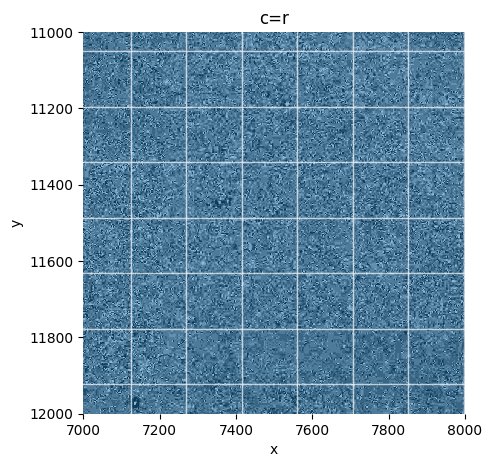

In [8]:
# lets plot the grid
sp.pl.plot_shapes( sdata,
                  img_layer="Visium_HD_Liver_full_image",
                  shapes_layer="Visium_HD_Liver_square_032um", 
                  crd = [7000,8000,11000, 12000],
                  channel = "r",
                  figsize=(5,5)
                   )

In [ ]:
# now do a custom binning using the generated labels layer 'square_labels'.
# below step should be quite fast, 50-ish seconds on mac m2
# sdata=sp.tb.bin_counts( 
#     sdata,
#     table_layer="square_002um",
#     labels_layer="Visium_HD_Liver_square_032um_labels",
#     output_layer="square_032um",
#     append = False,
#     overwrite=True,
#       )

2025-06-17 17:40:48,450 - sparrow.plot._plot - WARNING - There are '64' cells in provided shapes_layer 'Visium_HD_Liver_square_032um' not found in 'sdata.tables[square_032um]' (linked through 'cell_ID'), these cells will not be plotted.
2025-06-17 17:40:48,510 - sparrow.plot._plot - WARNING - Shapes layer Visium_HD_Liver_square_032um was empty for crd [7000, 8000, 11000, 12000].


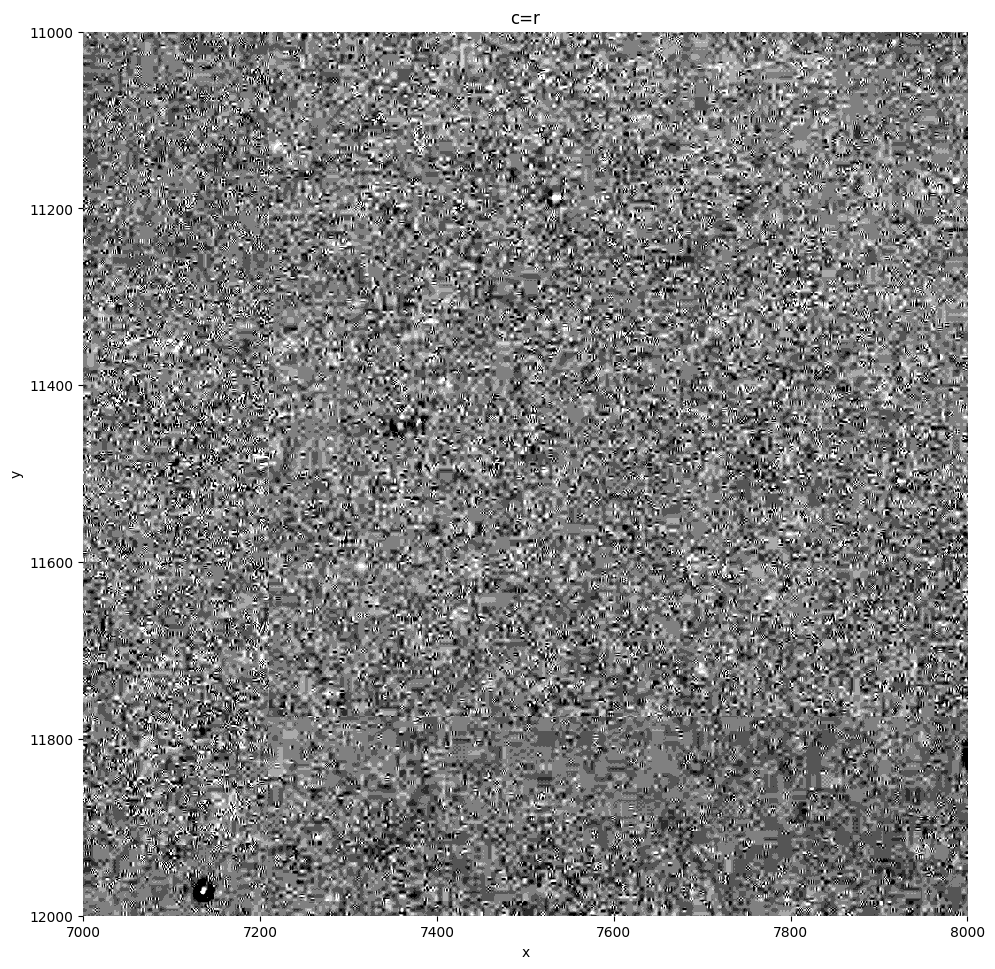

In [7]:
sp.pl.plot_shapes(
    sdata,
    img_layer = "Visium_HD_Liver_full_image",
    shapes_layer="Visium_HD_Liver_square_032um",
    crd = [7000,8000,11000, 12000],
    channel="r",
    table_layer = "square_032um",
    column="Clec4f",
    linewidth=0,
      )

In [20]:
sdata["Visium_HD_Liver_square_016um_labels"]

<xarray.DataArray 'image' (y: 419, x: 419)> Size: 702kB
dask.array<from-zarr, shape=(419, 419), dtype=uint32, chunksize=(419, 419), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 415.5 416.5 417.5 418.5
  * x        (x) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 415.5 416.5 417.5 418.5
Attributes:
    transform:  {'global': Sequence \n    Sequence \n        Affine (y, x -> ...

In [3]:
sdata["square_016um"].obs

,cell_ID,in_tissue,array_row,array_col,fov_labels
s_016um_00052_00082-1,21871,1,52,82,Visium_HD_Liver_square_016um_labels
s_016um_00163_00399-1,68697,1,163,399,Visium_HD_Liver_square_016um_labels
s_016um_00238_00388-1,100111,1,238,388,Visium_HD_Liver_square_016um_labels
s_016um_00144_00175-1,60512,1,144,175,Visium_HD_Liver_square_016um_labels
s_016um_00297_00147-1,124591,1,297,147,Visium_HD_Liver_square_016um_labels
...,...,...,...,...,...
s_016um_00212_00331-1,89160,1,212,331,Visium_HD_Liver_square_016um_labels
s_016um_00288_00288-1,120961,1,288,288,Visium_HD_Liver_square_016um_labels
s_016um_00193_00227-1,81095,1,193,227,Visium_HD_Liver_square_016um_labels
s_016um_00109_00223-1,45895,1,109,223,Visium_HD_Liver_square_016um_labels


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd

In [8]:
adata = sdata["square_032um"]
sc.pp.calculate_qc_metrics(adata, inplace=True)

<Axes: xlabel='n_genes_by_counts', ylabel='Count'>

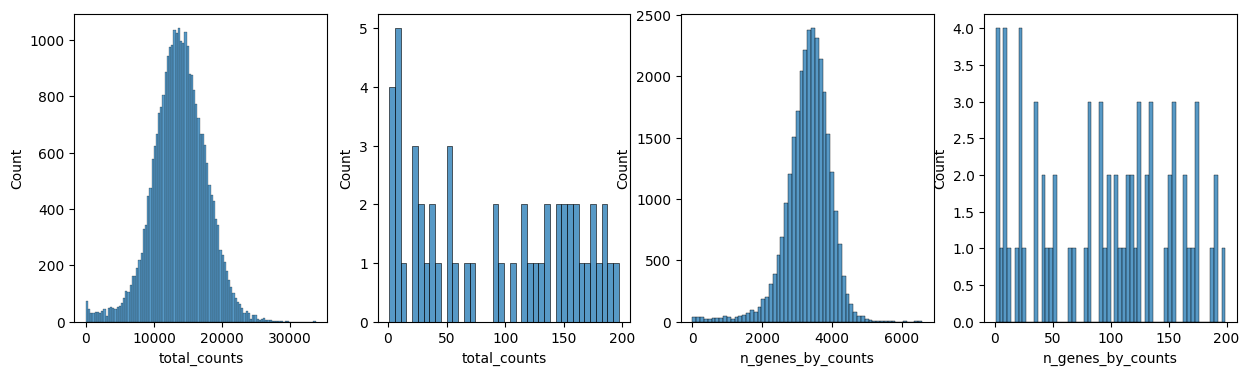

In [9]:


fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(
    adata.obs["total_counts"][adata.obs["total_counts"] < 200],
    kde=False,
    bins=40,
    ax=axs[1],
)
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(
    adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 200],
    kde=False,
    bins=60,
    ax=axs[3],
)

In [10]:
adata.write_h5ad("/home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_032um.h5ad")

In [13]:
adata.obs["cell_ID"]

cells
8686_Visium_HD_Liver_square_032um_labels_e00fd327      8686
8687_Visium_HD_Liver_square_032um_labels_e00fd327      8687
8688_Visium_HD_Liver_square_032um_labels_e00fd327      8688
8689_Visium_HD_Liver_square_032um_labels_e00fd327      8689
8690_Visium_HD_Liver_square_032um_labels_e00fd327      8690
                                                      ...  
73428_Visium_HD_Liver_square_032um_labels_e00fd327    73428
73429_Visium_HD_Liver_square_032um_labels_e00fd327    73429
73430_Visium_HD_Liver_square_032um_labels_e00fd327    73430
73431_Visium_HD_Liver_square_032um_labels_e00fd327    73431
73432_Visium_HD_Liver_square_032um_labels_e00fd327    73432
Name: cell_ID, Length: 29166, dtype: uint32

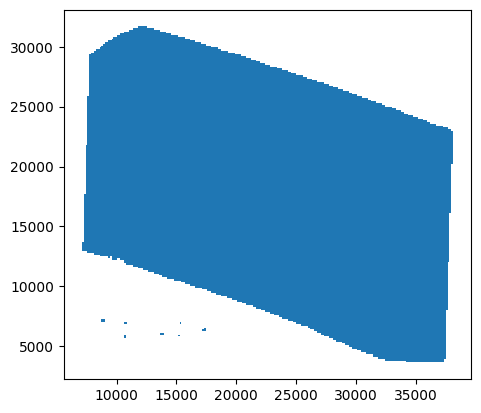

In [27]:
# Filter sdata["Visium_HD_Liver_square_032um"] to only include cells in adata.obs["cell_ID"]
cells_ids_in_tissue = sdata["Visium_HD_Liver_square_032um"].loc[adata.obs["cell_ID"]]
cells_ids_in_tissue.plot()

# Export the point object in two columns, x and y
df = pd.DataFrame({
    "x": cells_ids_in_tissue.centroid.x,
    "y": cells_ids_in_tissue.centroid.y
})

In [29]:
df.to_csv("/home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_032um_centroids.csv", index=True, header=True)